In [85]:
import pandas as pd
from dotenv import load_dotenv
import psycopg2
import os

In [86]:
load_dotenv()
url = os.getenv("DATABASE_URL")

In [87]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

query = """
SELECT timestamp, ticker, side, volume, price FROM orders
ORDER BY volume DESC
"""
cur.execute(query)
rows = cur.fetchall()

In [88]:
df = pd.DataFrame(rows, columns=['timestamp', 'ticker', 'side', 'volume', 'price'])
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()

,ticker,side,volume,price
timestamp,,,,
2026-04-29 16:47:14+00:00,SR320CF6,SELL,270000,12
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-26 15:18:50+00:00,SR320CP6A,SELL,74862,4
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9


In [89]:
biggest_trade = df.iloc[0]

In [90]:
query = """
SELECT timestamp, ticker, bids, asks FROM orderbooks
WHERE ticker = %s
ORDER BY id
"""
cur.execute(query, (biggest_trade.ticker,))
rows = cur.fetchall()

In [91]:
orderbook_df = pd.DataFrame(rows, columns = ['timestamp', 'ticker', 'bids', 'asks'])
orderbook_df['timestamp'] = pd.to_datetime(orderbook_df['timestamp'])
orderbook_df.set_index('timestamp', inplace=True)
orderbook_df.head()

,ticker,bids,asks
timestamp,,,
2026-04-15 05:02:39+00:00,SR320CF6,"[{'price': 0.02, 'quantity': 110}]",[]
2026-04-15 05:02:39+00:00,SR320CF6,"[{'price': 0.02, 'quantity': 110}]",[]
2026-04-15 05:02:39+00:00,SR320CF6,"[{'price': 0.02, 'quantity': 110}]",[]
2026-04-15 06:00:19+00:00,SR320CF6,"[{'price': 4.16, 'quantity': 1}, {'price': 0.0...",[]
2026-04-15 06:01:04+00:00,SR320CF6,"[{'price': 4.16, 'quantity': 1}, {'price': 2.3...","[{'price': 26.34, 'quantity': 500}]"


In [92]:
orderbook_df['best_bid'] = orderbook_df['bids'].apply(lambda x: max(x, key=lambda y: y['price'])['price'] if x else None)
orderbook_df['best_ask'] = orderbook_df['asks'].apply(lambda x: max(x, key=lambda y: y['price'])['price'] if x else None)
orderbook_df = orderbook_df[['ticker', 'best_bid', 'best_ask']]
orderbook_df.head()

,ticker,best_bid,best_ask
timestamp,,,
2026-04-15 05:02:39+00:00,SR320CF6,0.02,NaN
2026-04-15 05:02:39+00:00,SR320CF6,0.02,NaN
2026-04-15 05:02:39+00:00,SR320CF6,0.02,NaN
2026-04-15 06:00:19+00:00,SR320CF6,4.16,NaN
2026-04-15 06:01:04+00:00,SR320CF6,4.16,26.34


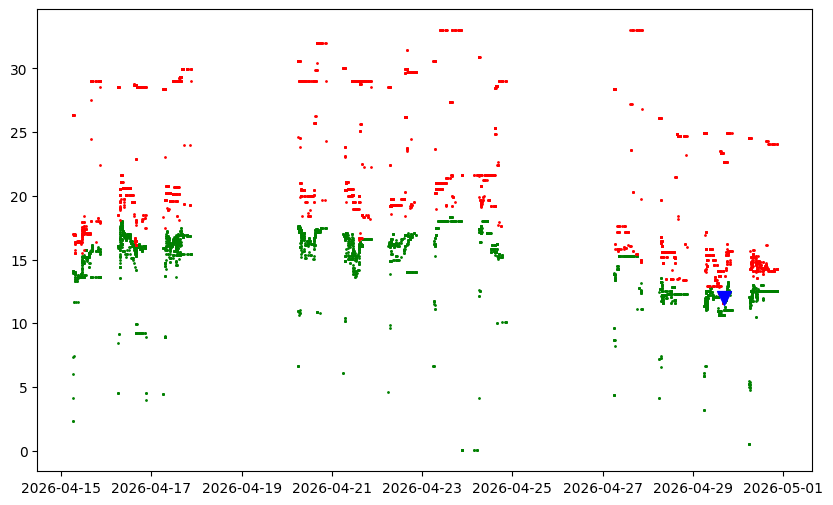

In [123]:
import matplotlib.pyplot as plt

orderbook_df.dropna(inplace=True)
orderbook_df['mid_price'] = (orderbook_df['best_ask'] + orderbook_df['best_ask'])/2


fig = plt.figure(figsize=(10, 6))
plt.scatter(orderbook_df.index, orderbook_df['best_bid'], color="green", s=1)
plt.scatter(orderbook_df.index, orderbook_df['best_ask'], color="red", s=1)

plt.scatter(biggest_trade.name, biggest_trade.price, marker="v", s=100, color="blue")